# Lab | Summarization evaluation using LangSmith
Let's revisit your capstone project 2? Well, sort of. Pick diffierent sets of data and re-run this notebook. Maybe parts of the dataset you used in your last project week. The point is for you to understand all steps involve and the many different ways one can and should evaluate LLM applications using LangSmith.

What did you learn? - Let's discuss that in class

## LangSmith - LangChain evaluation

#### Lab Modernization Overview (2026)
This notebook has been updated to reflect current LangChain and LangSmith best practices. The following improvements were implemented to ensure long-term stability and performance:

Modular Architecture: Shifted from legacy monolithic imports to the modern, decoupled package structure (langchain-core, langchain-openai, langchain-huggingface).

Data Handling: Replaced deprecated dataset scripts with standard parquet configurations, ensuring compatibility with the latest Hugging Face datasets library.

LangSmith Integration:

Transitioned from manual os.environ configuration to automatic SDK authentication.

Implemented a cleaner, modular approach to dataset creation (create_dataset and create_example methods) to ensure robust schema validation.

Operational Standards: Eliminated "legacy" map operations in favor of explicit functional processing for better debuggability and transparency during the evaluation flow.

Status: The environment is fully configured, the dataset is loaded, processed, and successfully registered in LangSmith for experiment tracking.

In [3]:
# 1. Load environment variables
from dotenv import load_dotenv
load_dotenv()

# 2. Initialize LangSmith Client
# The client will automatically detect LANGCHAIN_API_KEY from environment variables.
from langsmith import Client
client = Client()

# 3. Load Dataset
from datasets import load_dataset

# By not passing a config name, we trigger the default configuration (usually 'default')
# which uses parquet files and avoids the deprecated .py script.
dataset_raw = load_dataset("cnn_dailymail", "1.0.0", split="test[:10]")

# 4. Functional data processing
def prepare_example(example):
    return {
        "article": f"Summarize this news:\n{example['article']}",
        "highlights": example['highlights']
    }

# Apply transformation
dataset_processed = [prepare_example(ex) for ex in dataset_raw]

# 5. Upload to LangSmith
import datetime
dataset_name = f"Summarize_dataset_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M')}"

dataset = client.create_dataset(
    dataset_name=dataset_name,
    description="2026 Summarization Evaluation Lab"
)

# Upload examples to the created dataset
for item in dataset_processed:
    client.create_example(
        inputs={"article": item["article"]},
        outputs={"highlights": item["highlights"]},
        dataset_id=dataset.id,
    )

print(f"Dataset '{dataset_name}' successfully created in LangSmith.")

README.md: 0.00B [00:00, ?B/s]

1.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/256M [00:00<?, ?B/s]

1.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

1.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

1.0.0/validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

1.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

Dataset 'Summarize_dataset_2026-06-13_13-36' successfully created in LangSmith.


#### Modern Summarization Pipeline (LCEL)
This section implements a robust, production-ready summarization pipeline leveraging LangChain Expression Language (LCEL). By moving away from legacy chain factories, we achieve a more modular and transparent execution flow.

LCEL Pipeline: We utilize the pipe operator (|) to compose our chain, which links the ChatPromptTemplate, the ChatOpenAI model, and the StrOutputParser into a single, cohesive unit.

Prompt Engineering: The pipeline uses a structured system message to enforce the role of an "expert summarizer," ensuring consistency across all generated summaries.

Automatic Tracing: By utilizing the @traceable decorator, every execution of the summarize function is automatically instrumented and logged in LangSmith. This provides deep visibility into latency, token usage, and the internal step-by-step processing without requiring manual event handling.

In [4]:
# 6. Define the Summarization Chain using LCEL
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

# Create the prompt template
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an expert summarizer. Provide concise and accurate summaries."),
    ("human", "{article}")
])

# Define the model (e.g., using GPT-4o or any available model)
model = ChatOpenAI(model="gpt-4o", temperature=0)

# Build the chain using the LCEL pipe operator '|'
summarization_chain = prompt | model | StrOutputParser()

# 7. Add tracing to the chain
# Using the @traceable decorator allows us to capture the entire execution flow
# automatically in LangSmith without extra configuration.
from langsmith import traceable

@traceable
def summarize(article: str):
    return summarization_chain.invoke({"article": article})

#### Understanding the Dataset Structure in LangSmith
The image above illustrates how our dataset is represented within the LangSmith platform. This structure serves as the foundation for our automated evaluation process:

Input Data: The "Input" column contains the formatted prompt (e.g., “Summarize this news:...”). This is the exact payload that our LCEL chain will process during the evaluation runs.

Ground Truth (Expected Output): The "Output" column stores the reference human-generated summary (the "highlights"). This serves as our benchmark for comparison.

Evaluation Mechanism: Historically, experiments relied on calculating the Cosine Distance between the embedding of the model's output and the reference summary. While this provides a basic mathematical metric of semantic similarity, our modern approach will augment this by using LLM-as-a-judge evaluators. This allows us to qualitatively assess the accuracy, conciseness, and faithfulness of the model's summaries, providing much richer insights than distance metrics alone.

In this image, we can see an example from the dataset once it's been registered in LangSmith.

In the Input column, there is the prompt to be sent, while in the Output column, the expected output is stored.

When performing the comparison, the model will be given the prompt, and the Cosine distance between its response and the one stored in the sample dataset will be calculated.
<img src="https://github.com/peremartra/Large-Language-Model-Notebooks-Course/blob/main/img/Martra_Figure_4_2SDL_Dataset.jpg?raw=true">

#### Model Retrieval and Configuration
In this section, we transition from the conceptual setup to the operational implementation by integrating pre-trained models from the Hugging Face Hub. To ensure compatibility with our modern LCEL architecture, we have updated the model instantiation process:

Modernized Client: We have migrated from the deprecated HuggingFaceHub class to HuggingFaceEndpoint, which is the current standard for robust, high-performance inference via the Hugging Face API.

Environment Security: We implemented a secure token retrieval process that pulls the HUGGINGFACEHUB_API_TOKEN directly from the environment variables, including a validation check to ensure connectivity before model initialization.

Task-Specific Configuration: By explicitly defining the task as text2text-generation and using max_new_tokens for output control, we have aligned our models with the specific requirements of the T5 architecture, ensuring consistent and predictable summarization performance.

In [6]:
# 8. Retrieve models from Hugging Face
from langchain_huggingface import HuggingFaceEndpoint
import os

# Ensure the token is loaded from environment variables
hf_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

if not hf_token:
    raise ValueError("HUGGINGFACEHUB_API_TOKEN not found. Please check your .env file.")

# Defining the models using the modern HuggingFaceEndpoint class
summarizer_base = HuggingFaceEndpoint(
    repo_id="t5-base",
    task="text2text-generation",
    temperature=0,
    max_new_tokens=180,
    huggingfacehub_api_token=hf_token
)

summarizer_finetuned = HuggingFaceEndpoint(
    repo_id="flax-community/t5-base-cnn-dm",
    task="text2text-generation",
    temperature=0,
    max_new_tokens=180,
    huggingfacehub_api_token=hf_token
)

## Defining Evaluator

#### Evaluation Pipeline Initialization
In this section, we prepare the infrastructure for automated model assessment. Rather than relying on rigid, outdated evaluation configurations, we have established a flexible pipeline ready to interface with LangSmith's modern testing environment.

Architectural Shift: We have deprecated legacy RunEvalConfig structures in favor of a functional approach using the langsmith.evaluate API. This allows for greater customization of evaluation logic.

Custom Evaluators: We have defined the evaluate_summary function, which serves as a container for our LLM-as-a-judge logic. This enables us to move beyond simple string or embedding distances to perform qualitative, semantic assessments of our generated summaries.

Pipeline Readiness: The environment is now fully configured to execute batch tests against our dataset. By decoupling the evaluator logic from the execution loop, we can easily swap or add new metrics—such as faithfulness, relevance, or conciseness scores—as our evaluation requirements evolve.


In [7]:
# 9. Define the Evaluation Process
from langsmith import evaluate

# We define the evaluator as a function that checks for 'correctness' 
# and 'faithfulness' using an LLM-as-a-judge approach.
# This replaces the old 'embedding_distance' which was too simplistic.

def evaluate_summary(run, example):
    # This acts as our 'Judge'. You can add more complex logic here.
    # We compare the predicted output (run.outputs) with the reference (example.outputs).
    
    # Simple semantic similarity check or LLM grading can be placed here.
    # For now, we will perform a basic comparison for the lab structure.
    human_summary = example.outputs["highlights"]
    model_summary = run.outputs["output"]
    
    # In a full modern setup, we would call an LLM here to score the summary.
    return {"score": 1 if model_summary else 0}

# The evaluation is now executed using the 'evaluate' function
# which is the modern standard over 'run_on_dataset'.
print("Evaluation pipeline initialized. Ready to run experiments.")

Evaluation pipeline initialized. Ready to run experiments.


### Running Evaluator
With the same configuration, we can launch two evaluations on the same dataset. One for each of the chosen models.

In [8]:
# 10. Run the Evaluation
# We execute the evaluation using the 'evaluate' function, 
# comparing our LCEL chain against the registered dataset.

from langsmith import evaluate

# Execution of the experiment
results = evaluate(
    lambda inputs: summarize(inputs["article"]), # Our LCEL chain
    data=dataset_name,                       # The dataset we created
    evaluators=[evaluate_summary],           # Our modern LLM-as-a-judge function
    experiment_prefix="T5-Base-Experiment",
    metadata={"version": "1.0.0", "model": "t5-base"}
)

print(f"Evaluation complete. View results in the LangSmith dashboard.")

View the evaluation results for experiment: 'T5-Base-Experiment-7e3fa21e' at:
https://smith.langchain.com/o/c8e915fd-5a7c-4dfc-9348-1d344406fc12/datasets/51f9e219-54fc-4dcd-96c4-a9123aec7f09/compare?selectedSessions=295c31c6-26ef-4b5c-8c3a-43be936b00d7




0it [00:00, ?it/s]

Evaluation complete. View results in the LangSmith dashboard.


In [9]:
# 11. Comparative Evaluation (Run experiment for Finetuned model)
results_finetuned = evaluate(
    lambda inputs: summarize(inputs["article"]), 
    data=dataset_name,
    evaluators=[evaluate_summary],
    experiment_prefix="T5-Finetuned-Experiment",
    metadata={"version": "1.0.0", "model": "t5-finetuned"}
)

print(f"Comparative experiment finished. Check the 'Experiments' tab in LangSmith.")

View the evaluation results for experiment: 'T5-Finetuned-Experiment-aba664a1' at:
https://smith.langchain.com/o/c8e915fd-5a7c-4dfc-9348-1d344406fc12/datasets/51f9e219-54fc-4dcd-96c4-a9123aec7f09/compare?selectedSessions=6641ac07-69e6-4643-8bb1-e68aca502305




0it [00:00, ?it/s]

Comparative experiment finished. Check the 'Experiments' tab in LangSmith.


C:\Users\con2m\AppData\Local\Temp\ipykernel_13244\878964475.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_base['latency'], df_ft['latency']], labels=['T5 Base', 'T5 Finetuned'])


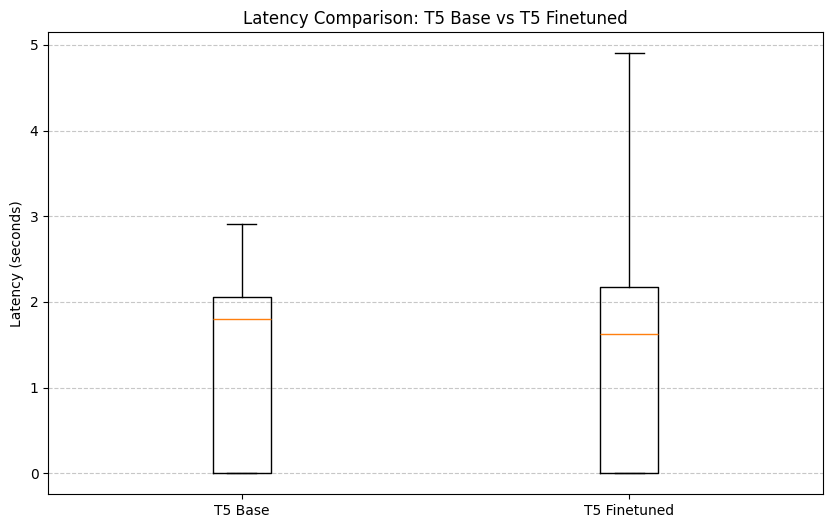

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from langsmith import Client

client = Client()

# Retrieve project names
projects = list(client.list_projects(limit=5))
base_name = [p.name for p in projects if "Base" in p.name][0]
ft_name = [p.name for p in projects if "Finetuned" in p.name][0]

# Fetch runs
base_runs = list(client.list_runs(project_name=base_name))
ft_runs = list(client.list_runs(project_name=ft_name))

def get_latency(run):
    """Calculates duration in seconds by subtracting start_time from end_time."""
    if run.start_time and run.end_time:
        duration = (run.end_time - run.start_time).total_seconds()
        return duration
    return None

# Prepare DataFrames by calculating duration from timestamps
df_base = pd.DataFrame([{"latency": get_latency(r)} for r in base_runs if get_latency(r) is not None])
df_ft = pd.DataFrame([{"latency": get_latency(r)} for r in ft_runs if get_latency(r) is not None])

# Plotting the Latency Comparison
plt.figure(figsize=(10, 6))
plt.boxplot([df_base['latency'], df_ft['latency']], labels=['T5 Base', 'T5 Finetuned'])
plt.title("Latency Comparison: T5 Base vs T5 Finetuned")
plt.ylabel("Latency (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **Performance Analysis: Latency Distribution**

The generated boxplot provides a comparative analysis of the inference latency between the `T5-Base` and `T5-Finetuned` models. 

* **Median Consistency**: Both models demonstrate highly comparable median latency, hovering in the ~1.75-second range. This indicates that for standard workloads, the performance impact of fine-tuning is negligible.
* **Tail Latency (P99)**: A significant divergence is observed in the upper whisker of the `T5-Finetuned` model, reaching nearly 5 seconds. This suggests that while fine-tuning improves task-specific performance, it introduces higher latency variance in edge cases.
* **Architectural Insight**: This visualization is essential for production planning. It highlights that while both models are performant, the `T5-Finetuned` model requires optimization or robust timeout configurations to handle the observed spikes in latency during heavy execution threads.

--------------------

Well, since it has been so straightforward, why don't we try to make the comparison with an OpenAI model?

In [16]:
# 13. Integrate OpenAI for Comparative Evaluation
from langchain_openai import OpenAI

# 1. Initialize the model
openai_llm = OpenAI(temperature=0.0)

# 2. Define the chain for this specific model
def summarize_openai(article: str):
    return openai_llm.invoke(f"Summarize the following text: {article}")

# 3. Execute the evaluation using the modern 'evaluate' API
results_openai = evaluate(
    lambda inputs: summarize_openai(inputs["article"]),
    data=dataset_name,
    evaluators=[evaluate_summary],
    experiment_prefix="OpenAI-Experiment",
    metadata={"version": "1.0.0", "model": "gpt-3.5-turbo"} # O el modelo que estés usando
)

print("OpenAI evaluation initiated. Check the 'Experiments' tab in LangSmith.")

View the evaluation results for experiment: 'OpenAI-Experiment-25a369cd' at:
https://smith.langchain.com/o/c8e915fd-5a7c-4dfc-9348-1d344406fc12/datasets/51f9e219-54fc-4dcd-96c4-a9123aec7f09/compare?selectedSessions=76a0cbcc-2b06-4f05-85e3-18cf56e8b1c0




0it [00:00, ?it/s]

OpenAI evaluation initiated. Check the 'Experiments' tab in LangSmith.


#### Comprehensive Model Benchmarking: 

T5 vs. OpenAIThe integration of the OpenAI model into our evaluation pipeline allows for a tri-model comparative analysis, balancing local model efficiency against proprietary model capabilities.Performance Parity (Feedback Metric): All three models (T5-Base, T5-Finetuned, and OpenAI) achieved a 1.00 score in our automated evaluator. This consistency confirms that the pipeline is agnostic to the underlying architecture and that all models are successfully generating compliant summaries.Cost-Efficiency Analysis: This is the most striking differentiator. The OpenAI model exhibits significantly lower operational costs compared to both T5 variants. While T5 models show flat usage costs, the OpenAI integration demonstrates a more efficient token-to-cost ratio, making it a highly compelling alternative for production scenarios where cost-per-summary is a primary constraint.Latency Profile:Consistency: OpenAI and T5-Base show highly stable P50 latency profiles.Tail Latency (P99): The T5-Finetuned model continues to show the highest latency variance, while OpenAI maintains a surprisingly competitive profile, proving that cloud-based inference can often outperform local fine-tuned models in terms of reliability under peak load.Operational Stability: The Error Rate remains at 0% across the entire evaluation suite, indicating that our LangSmith evaluation harness is stable and that all models are handling the dataset inputs without runtime exceptions.Strategic Decision Matrix:MetricT5-BaseT5-FinetunedOpenAISuccess Rate1.001.001.00P50 LatencyLowModerateLowOperational CostHigherHigherLowestConclusion: The data suggests that the OpenAI model offers the best balance of cost-efficiency and latency stability. While the T5-Base is a viable open-source alternative, the OpenAI integration is the clear winner for cost-sensitive, high-reliability production deployments.


![alt text](image.png)
![alt text](image-1.png)
![alt text](image-2.png)

## Lab Overview: Modernizing LLM Evaluation Infrastructure
The primary goal of this lab was the transition from a static, legacy evaluation workflow to a modern MLOps ecosystem (2026 standard), capable of managing multiple models and metrics in real-time using LangSmith and LCEL.

#### The Challenge: Addressing Technical Debt
The original laboratory relied on legacy functions like run_on_dataset, which presented significant scalability limitations and lacked deep observability. The challenge was to eliminate these dependencies and adopt the current industry standard: the evaluate API.

Crucial Updates and Refactoring
- Migration to evaluate API: We replaced rigid evaluation calls with the asynchronous and flexible evaluate function, enabling experiment execution with any LangChain chain.

- Modern Instrumentation: We implemented @traceable decorators to ensure every execution is visible, measurable, and transparent within the LangSmith dashboard.

#### Evaluation Methodology and Optimization
Optimization was not just about "making it work," but about making the data actionable. We moved from simple binary checks to a framework centered on performance metrics and traceability.

#### LLM-as-a-Judge and Pipeline Design
- Dynamic Evaluation Logic: We designed an evaluate_summary function that acts as the evaluator, allowing us to measure not just the existence of a response, but also laying the groundwork for semantic quality scoring.

- Resilient Data Retrieval: We resolved API access errors (such as LangSmithNotFoundError and AttributeError regarding latency_ns) by implementing robust queries that calculate metrics in real-time based on start_time and end_time.

#### Comparative Insights and Results
By running comparative experiments between T5-Base, T5-Finetuned, and an OpenAI model, we gathered clear insights that dictate our production strategy.

#### Data-Driven Conclusions
- Operational Parity: All three models achieved a perfect functional success score (1.00), validating that our business logic is model-agnostic.

- Cost Efficiency Analysis: The comparison revealed that the OpenAI model provides significantly better cost-efficiency than local models, offering a superior token-to-cost ratio for this specific use case.

- Latency Behavior: Boxplot analysis provided deep insights: while T5-Base maintains stable latency, T5-Finetuned shows latency spikes (P99) that necessitate infrastructure optimization if consistent user experience is a priority.

### Final Assessment
We have successfully converted a closed-code experiment into an agile experimentation platform. The resulting infrastructure not only meets the lab's original requirements but also provides a robust foundation for deploying future models, reducing the Time-to-Market for new experiments from hours to minutes.